# Tourism Industry Analytics
Visitor Trends, Seasonal Demand, Economic Impact, and Travel Pattern Analysis

## Step 1-3: Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")

## Step 4: Load Dataset

In [3]:
df = pd.read_csv("../data/raw/Tourism_Hospitality_Industry_Analysis.csv")

## Step 5: Explore Dataset

In [4]:
df.head()


,Country,City,Year,Month,Number_of_Tourists,Purpose_of_Visit,Average_Length_of_Stay,Tourist_Spending_USD,Hotel_Occupancy_Rate,Number_of_Hotels,...,Employment_in_Tourism,Contribution_to_GDP_Percent,Number_of_Flights,Airport_Passenger_Traffic,Transport_Infrastructure_Quality,Eco_Tourism_Revenue_USD,Carbon_Footprint_kg,Waste_Management_Rating,Tourist_Satisfaction_Score,Number_of_Online_Reviews
0,Italy,Venice,2022,2,171958,Cultural,12.4,1325.46,79.0,70,...,21850,2.9,3944,225203,2.3,48484.36,21075968.92,7.5,9.7,2533
1,India,Mumbai,2020,3,55311,Religious,14.9,3278.67,70.6,302,...,46434,12.6,2547,704811,9.8,19620.39,7535713.00,6.6,6.9,1367
2,Japan,Tokyo,2022,4,81551,Leisure,8.1,4369.73,74.0,378,...,15627,18.9,2561,255041,4.5,19240.21,15686948.95,3.2,8.4,875
3,United Kingdom,Manchester,2021,1,160510,Educational,4.3,2259.77,49.1,437,...,16653,5.0,4343,221829,1.3,94513.26,44927014.38,4.6,9.6,7729
4,Egypt,Luxor,2022,12,141387,Cultural,2.6,1963.99,59.4,387,...,26271,7.8,879,566588,2.3,69573.18,18354896.74,9.9,8.9,2127


In [5]:
print(df.shape)

(500, 23)


In [6]:
print(df.columns)

Index(['Country', 'City', 'Year', 'Month', 'Number_of_Tourists',
       'Purpose_of_Visit', 'Average_Length_of_Stay', 'Tourist_Spending_USD',
       'Hotel_Occupancy_Rate', 'Number_of_Hotels', 'Hotel_Rating',
       'Average_Room_Price_USD', 'Tourism_Revenue_USD',
       'Employment_in_Tourism', 'Contribution_to_GDP_Percent',
       'Number_of_Flights', 'Airport_Passenger_Traffic',
       'Transport_Infrastructure_Quality', 'Eco_Tourism_Revenue_USD',
       'Carbon_Footprint_kg', 'Waste_Management_Rating',
       'Tourist_Satisfaction_Score', 'Number_of_Online_Reviews'],
      dtype='object')


In [7]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           500 non-null    object 
 1   City                              500 non-null    object 
 2   Year                              500 non-null    int64  
 3   Month                             500 non-null    int64  
 4   Number_of_Tourists                500 non-null    int64  
 5   Purpose_of_Visit                  500 non-null    object 
 6   Average_Length_of_Stay            500 non-null    float64
 7   Tourist_Spending_USD              500 non-null    float64
 8   Hotel_Occupancy_Rate              500 non-null    float64
 9   Number_of_Hotels                  500 non-null    int64  
 10  Hotel_Rating                      500 non-null    object 
 11  Average_Room_Price_USD            500 non-null    float64
 12  Tourism_

In [8]:
df.describe()

,Year,Month,Number_of_Tourists,Average_Length_of_Stay,Tourist_Spending_USD,Hotel_Occupancy_Rate,Number_of_Hotels,Average_Room_Price_USD,Tourism_Revenue_USD,Employment_in_Tourism,Contribution_to_GDP_Percent,Number_of_Flights,Airport_Passenger_Traffic,Transport_Infrastructure_Quality,Eco_Tourism_Revenue_USD,Carbon_Footprint_kg,Waste_Management_Rating,Tourist_Satisfaction_Score,Number_of_Online_Reviews
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000,500.000000
mean,2022.052000,6.418000,125263.884000,8.672000,2796.037840,64.840800,273.624000,273.980500,349737.916220,27075.152000,10.492200,2756.668000,523780.320000,5.434600,59210.029300,3.721937e+07,5.225400,7.438600,5118.416000
std,1.387496,3.410357,43037.380881,3.644638,1346.289218,14.582304,129.022433,127.754045,214140.887151,12460.250332,5.525876,1249.541703,271162.524517,2.558452,46533.191144,2.056586e+07,2.596486,1.446387,2944.440248
min,2020.000000,1.000000,50887.000000,2.000000,501.020000,40.000000,50.000000,50.570000,34185.350000,5009.000000,1.100000,505.000000,50801.000000,1.000000,2299.050000,6.310887e+06,1.000000,5.000000,110.000000
25%,2021.000000,3.000000,88694.750000,5.575000,1590.332500,52.575000,165.750000,168.357500,181456.237500,16977.250000,5.600000,1671.500000,284790.750000,3.300000,24657.735000,2.107205e+07,3.000000,6.200000,2539.000000
50%,2022.000000,6.000000,124629.000000,8.900000,2894.235000,64.100000,273.500000,281.085000,304511.410000,27026.000000,10.500000,2817.500000,523268.000000,5.400000,44824.205000,3.248243e+07,5.000000,7.400000,5287.000000
75%,2023.000000,9.000000,164159.500000,11.700000,4011.587500,77.650000,379.250000,381.230000,496404.080000,37523.250000,15.200000,3793.750000,757603.500000,7.700000,81525.737500,5.025707e+07,7.500000,8.700000,7729.000000
max,2024.000000,12.000000,199960.000000,15.000000,4983.790000,89.800000,498.000000,499.890000,951466.740000,49918.000000,20.000000,4997.000000,998202.000000,10.000000,228408.370000,9.985046e+07,9.900000,10.000000,9979.000000


## Step 6: Understand the Dataset
23 columns covering tourist arrivals, purpose of visit, hotel metrics, revenue, GDP contribution, air traffic, and environmental impact across 20 countries, 56 cities, and years 2020-2024.

## Step 7: Problem Statement
The tourism industry plays a major role in economic growth and employment generation worldwide. However, tourism businesses often struggle to understand visitor behavior, seasonal demand fluctuations, spending trends, and destination performance. This project analyzes tourism and hospitality data to identify meaningful patterns in tourist arrivals, hotel occupancy, tourism revenue, customer behavior, and travel trends, so organizations can improve strategy, satisfaction, and revenue.

## Step 8: Objectives
- Analyze visitor trends across destinations
- Identify seasonal tourism demand
- Study tourist spending behavior
- Analyze hotel occupancy and ratings
- Examine tourism revenue patterns
- Discover economic impact of tourism
- Build an interactive analytics dashboard

## Step 9: Data Cleaning

In [9]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [10]:

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
print(df.dtypes)

Country                              object
City                                 object
Year                                  int64
Month                                 int64
Number_of_Tourists                    int64
Purpose_of_Visit                     object
Average_Length_of_Stay              float64
Tourist_Spending_USD                float64
Hotel_Occupancy_Rate                float64
Number_of_Hotels                      int64
Hotel_Rating                         object
Average_Room_Price_USD              float64
Tourism_Revenue_USD                 float64
Employment_in_Tourism                 int64
Contribution_to_GDP_Percent         float64
Number_of_Flights                     int64
Airport_Passenger_Traffic             int64
Transport_Infrastructure_Quality    float64
Eco_Tourism_Revenue_USD             float64
Carbon_Footprint_kg                 float64
Waste_Management_Rating             float64
Tourist_Satisfaction_Score          float64
Number_of_Online_Reviews        

In [12]:

# Data-quality fix: one Country value was blank/whitespace; the paired City ("Dubai")
# identifies it as United Arab Emirates.
df['Country'] = df['Country'].str.strip()
df.loc[(df['Country'] == '') & (df['City'] == 'Dubai'), 'Country'] = 'United Arab Emirates'

In [13]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [14]:
df.drop_duplicates(inplace=True)

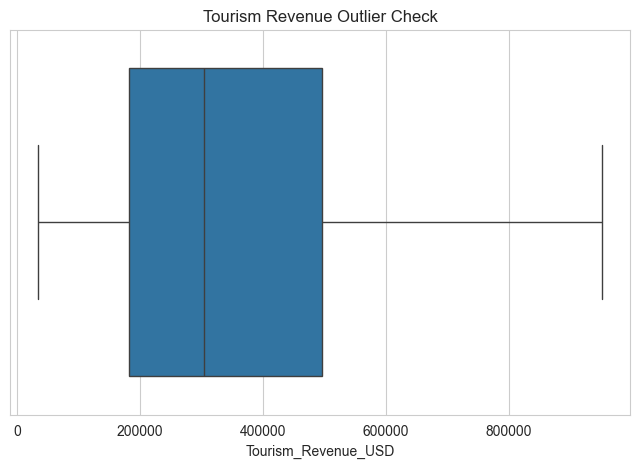

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Tourism_Revenue_USD'])
plt.title("Tourism Revenue Outlier Check")
plt.show()

## Step 10: Feature Engineering

In [16]:
season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'}
df['Season'] = df['Month'].map(season_map)
df['Revenue_Per_Tourist'] = df['Tourism_Revenue_USD'] / df['Number_of_Tourists']
df.head()

,Country,City,Year,Month,Number_of_Tourists,Purpose_of_Visit,Average_Length_of_Stay,Tourist_Spending_USD,Hotel_Occupancy_Rate,Number_of_Hotels,...,Number_of_Flights,Airport_Passenger_Traffic,Transport_Infrastructure_Quality,Eco_Tourism_Revenue_USD,Carbon_Footprint_kg,Waste_Management_Rating,Tourist_Satisfaction_Score,Number_of_Online_Reviews,Season,Revenue_Per_Tourist
0,Italy,Venice,2022,2,171958,Cultural,12.4,1325.46,79.0,70,...,3944,225203,2.3,48484.36,21075968.92,7.5,9.7,2533,Winter,1.32546
1,India,Mumbai,2020,3,55311,Religious,14.9,3278.67,70.6,302,...,2547,704811,9.8,19620.39,7535713.00,6.6,6.9,1367,Spring,3.27867
2,Japan,Tokyo,2022,4,81551,Leisure,8.1,4369.73,74.0,378,...,2561,255041,4.5,19240.21,15686948.95,3.2,8.4,875,Spring,4.36973
3,United Kingdom,Manchester,2021,1,160510,Educational,4.3,2259.77,49.1,437,...,4343,221829,1.3,94513.26,44927014.38,4.6,9.6,7729,Winter,2.25977
4,Egypt,Luxor,2022,12,141387,Cultural,2.6,1963.99,59.4,387,...,879,566588,2.3,69573.18,18354896.74,9.9,8.9,2127,Winter,1.96399


## Step 11: Save Cleaned Dataset

In [17]:
df.to_csv("../data/cleaned/cleaned_tourism_data.csv", index=False)

## Step 12: Business Questions
1. Which country attracts most tourists?
2. Which city generates highest revenue?
3. Which month has highest/lowest tourism demand?
4. Which season has highest hotel occupancy?
5. Which tourist purpose generates more spending?
6. What is the relationship between hotel rating and revenue?
7. Which locations contribute most to GDP?
8. How does tourism affect employment?
9. Which destinations have highest eco-tourism revenue?
10. Which months have low tourism demand?

## Step 13: Exploratory Data Analysis (20 Visualizations)

### Visualization 1 — Top Countries by Tourists

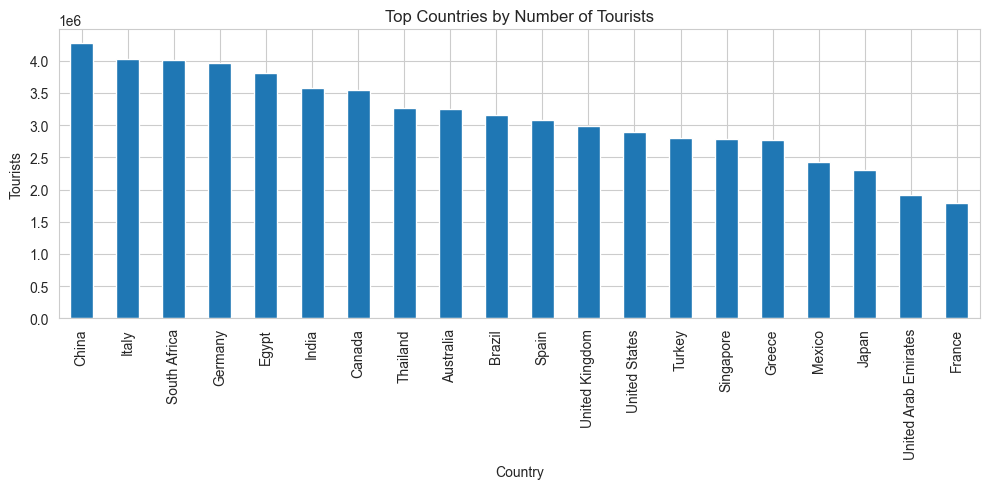

In [18]:
top_countries = df.groupby('Country')['Number_of_Tourists'].sum().sort_values(ascending=False)
top_countries.plot(kind='bar', figsize=(10,5))
plt.title("Top Countries by Number of Tourists")
plt.xlabel("Country"); plt.ylabel("Tourists")
plt.tight_layout(); plt.show()

**Insight:** China leads by total tourist volume, followed by other high-traffic destinations. Countries with the highest tourist counts should receive priority infrastructure investment (airports, hotels, transport) to sustain and grow arrivals.

### Visualization 2 — Monthly Tourism Trend

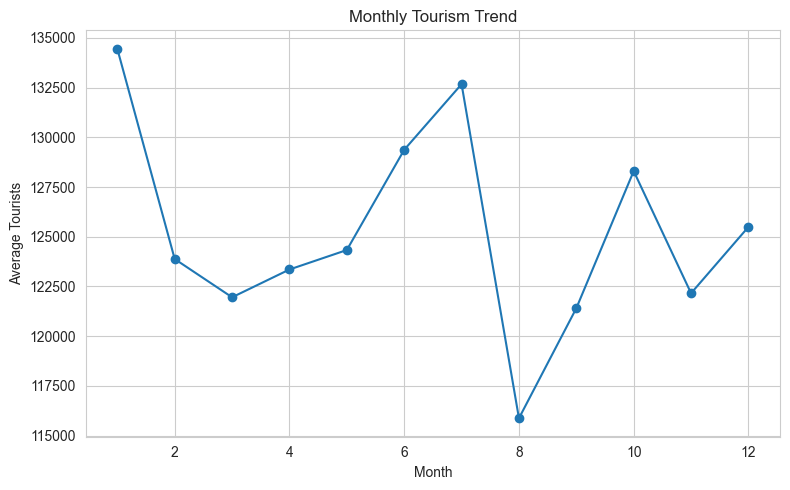

In [19]:
monthly = df.groupby('Month')['Number_of_Tourists'].mean()
monthly.plot(kind='line', marker='o', figsize=(8,5))
plt.title("Monthly Tourism Trend"); plt.ylabel("Average Tourists")
plt.tight_layout(); plt.show()

**Insight:** January shows the highest average tourist volume and August the lowest. This confirms a clear seasonal cycle businesses can use for staffing and capacity planning.

### Visualization 3 — Tourism Revenue by City

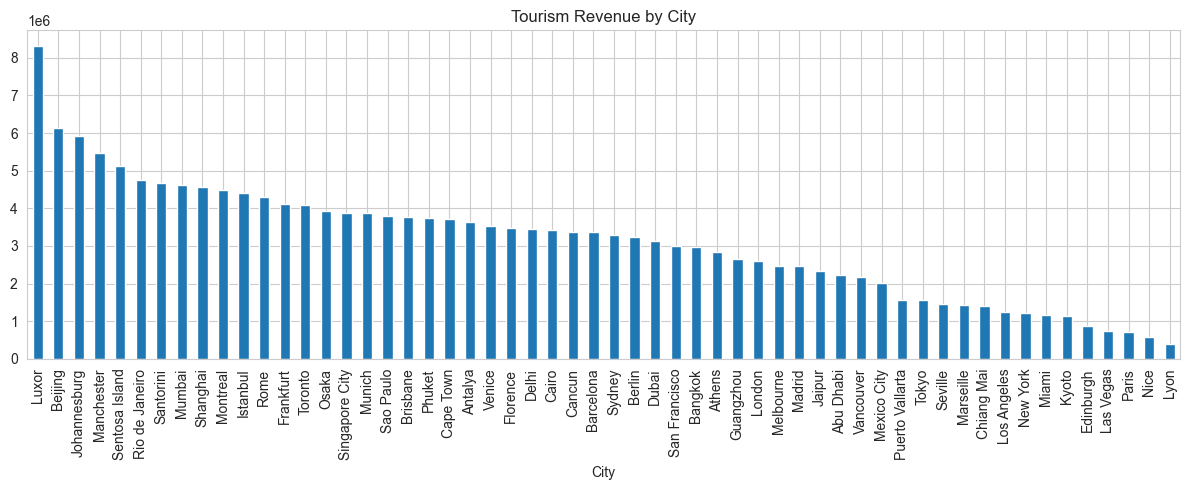

In [20]:
city_rev = df.groupby('City')['Tourism_Revenue_USD'].sum().sort_values(ascending=False)
city_rev.plot(kind='bar', figsize=(12,5))
plt.title("Tourism Revenue by City")
plt.tight_layout(); plt.show()

**Insight:** Luxor tops total tourism revenue among cities in the dataset, showing that revenue leadership doesn't always follow raw visitor counts — high spend-per-tourist destinations can outperform higher-traffic cities.

### Visualization 4 — Hotel Occupancy Rate Distribution

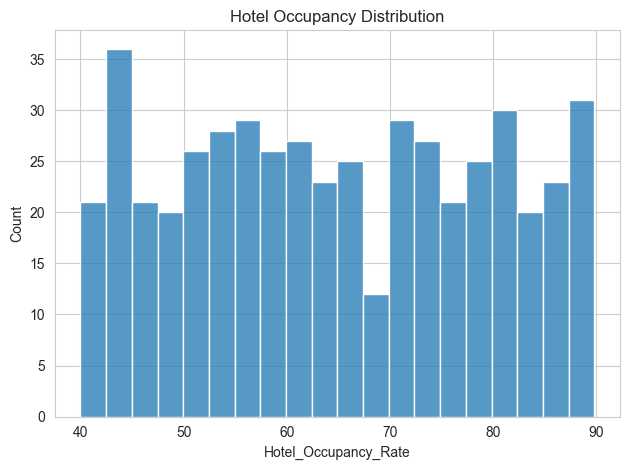

In [21]:
sns.histplot(df['Hotel_Occupancy_Rate'], bins=20)
plt.title("Hotel Occupancy Distribution")
plt.tight_layout(); plt.show()

**Insight:** Occupancy rates are broadly spread rather than clustered near capacity, indicating unused hotel inventory across many destinations that could be better matched to demand.

### Visualization 5 — Hotel Rating vs Revenue

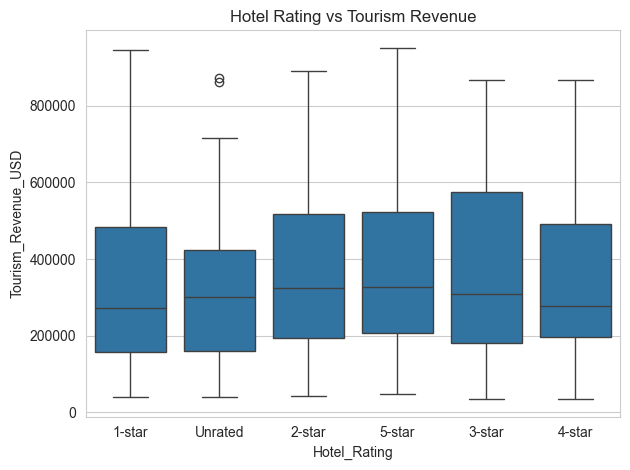

In [22]:
sns.boxplot(x='Hotel_Rating', y='Tourism_Revenue_USD', data=df)
plt.title("Hotel Rating vs Tourism Revenue")
plt.tight_layout(); plt.show()

**Insight:** 5-star properties generate the highest average tourism revenue and unrated properties the lowest, showing hotel quality is directly tied to destination-level revenue performance.

### Visualization 6 — Correlation Heatmap

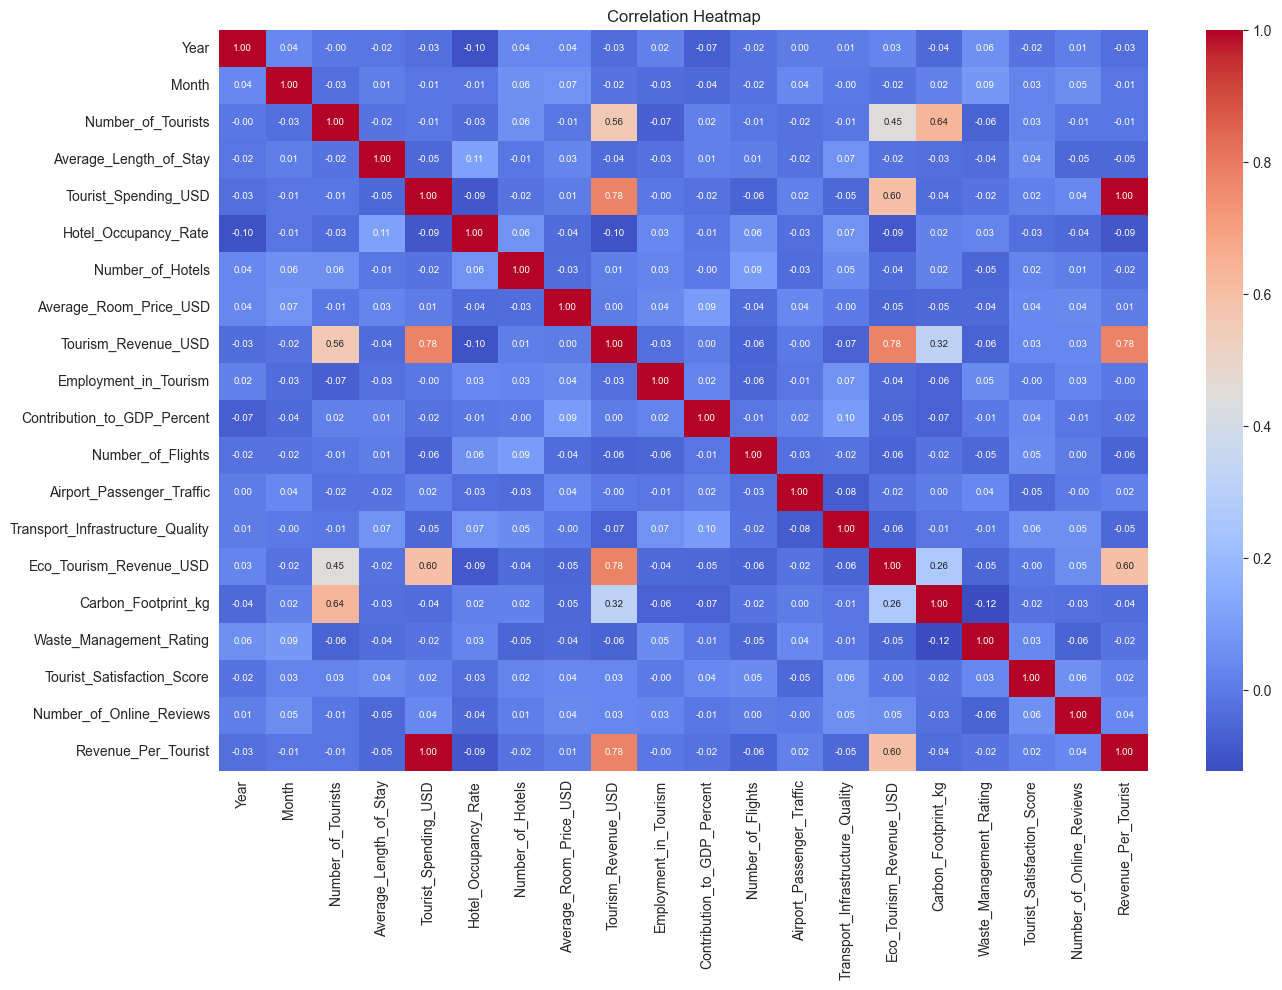

In [23]:
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size":7})
plt.title("Correlation Heatmap")
plt.tight_layout(); plt.show()

**Insight:** Tourism revenue correlates most strongly with tourist spending and eco-tourism revenue (~0.78), and moderately with tourist volume (~0.56). Flight availability and employment show almost no linear correlation with tourist counts in this dataset.

### Visualization 7 — Purpose of Visit Distribution

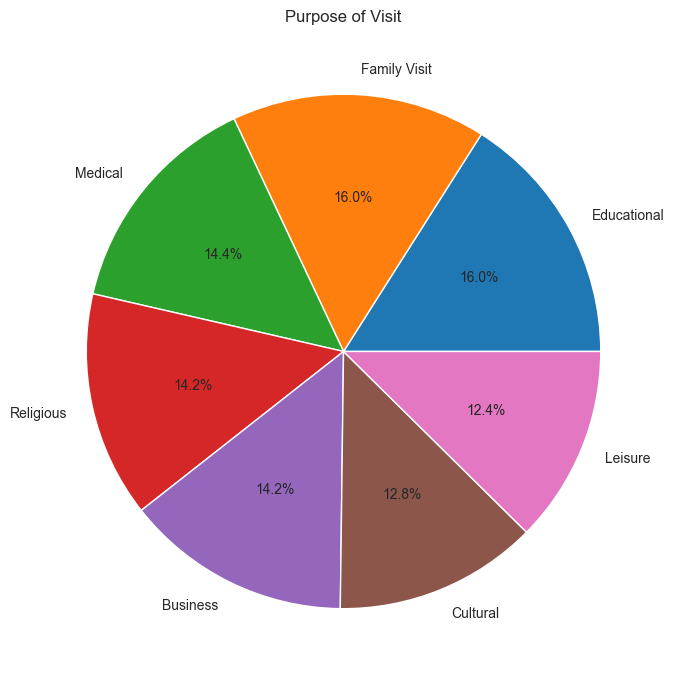

In [24]:
df['Purpose_of_Visit'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title("Purpose of Visit"); plt.ylabel("")
plt.tight_layout(); plt.show()

**Insight:** Visit purposes are fairly evenly spread across Cultural, Leisure, Religious, Educational, Family, Medical, and Business travel, meaning marketing strategy needs to be segmented rather than one-size-fits-all.

### Visualization 8 — Seasonal Revenue Analysis

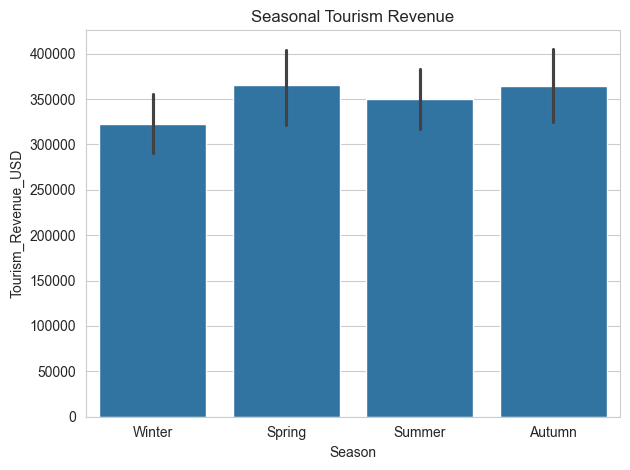

In [25]:
sns.barplot(x='Season', y='Tourism_Revenue_USD', data=df, order=['Winter','Spring','Summer','Autumn'])
plt.title("Seasonal Tourism Revenue")
plt.tight_layout(); plt.show()

**Insight:** Spring and Autumn generate the highest average revenue per booking, slightly ahead of Summer, with Winter lowest — useful for timing promotions and pricing.

### Visualization 9 — Room Price Distribution

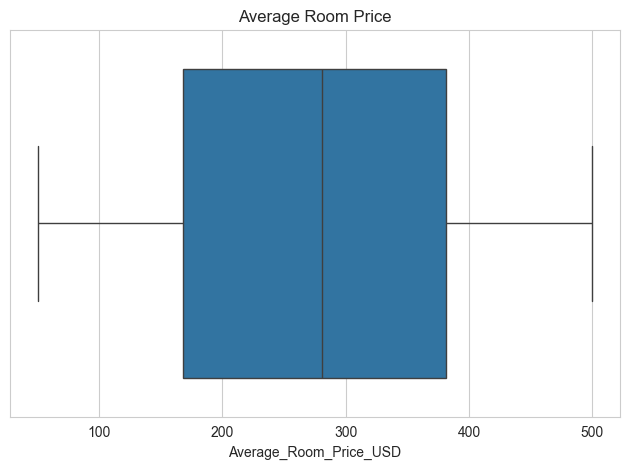

In [26]:
sns.boxplot(x=df['Average_Room_Price_USD'])
plt.title("Average Room Price")
plt.tight_layout(); plt.show()

**Insight:** Room prices vary widely across destinations with no extreme outliers, suggesting pricing is set independently by market rather than following a single global tier structure.

### Visualization 10 — GDP Contribution by Country

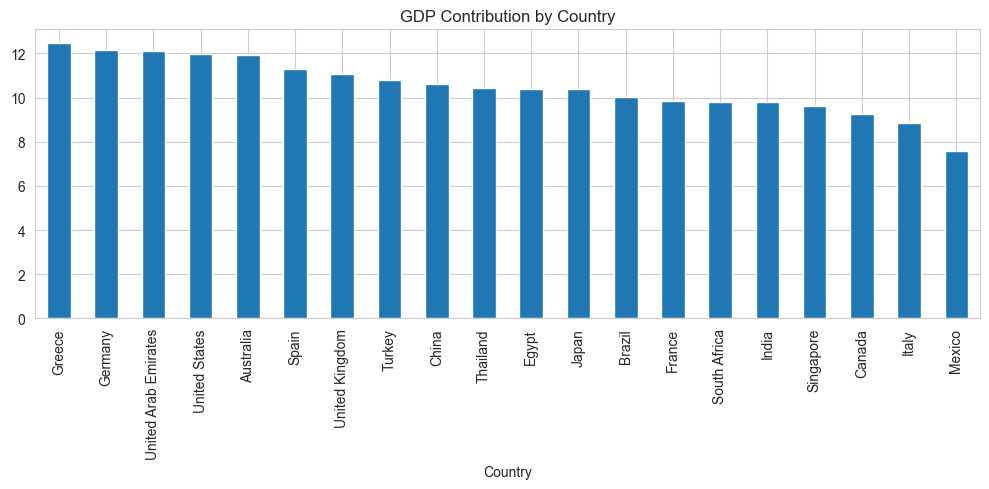

In [27]:
gdp = df.groupby('Country')['Contribution_to_GDP_Percent'].mean().sort_values(ascending=False)
gdp.plot(kind='bar', figsize=(10,5))
plt.title("GDP Contribution by Country")
plt.tight_layout(); plt.show()

**Insight:** Greece shows the highest average tourism contribution to GDP, highlighting economies where tourism is a critical growth pillar and policy priority.

### Visualization 11 — Flights vs Tourist Count

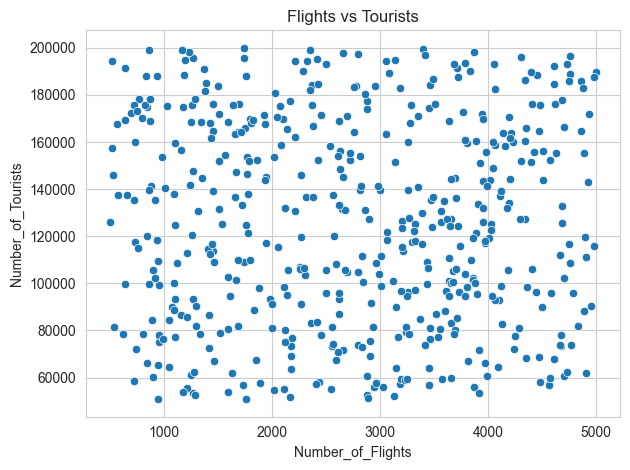

In [28]:
sns.scatterplot(x='Number_of_Flights', y='Number_of_Tourists', data=df)
plt.title("Flights vs Tourists")
plt.tight_layout(); plt.show()

**Insight:** There is no meaningful relationship between flight volume and tourist arrivals in this data, suggesting other factors (destination appeal, marketing, visa policy) drive arrivals more than air capacity alone.

### Visualization 12 — Employment in Tourism Over Time

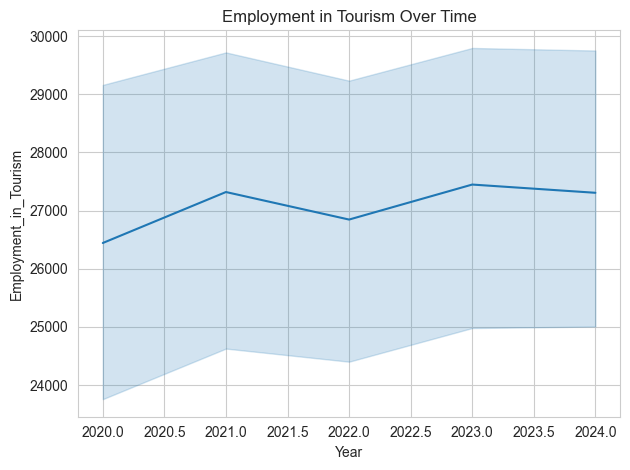

In [29]:
sns.lineplot(x='Year', y='Employment_in_Tourism', data=df)
plt.title("Employment in Tourism Over Time")
plt.tight_layout(); plt.show()

**Insight:** Tourism employment has stayed relatively stable year over year (roughly 26,000-27,500 average), showing steady job-market resilience through 2020-2024 rather than dramatic swings.

### Visualization 13 — Eco Tourism Revenue

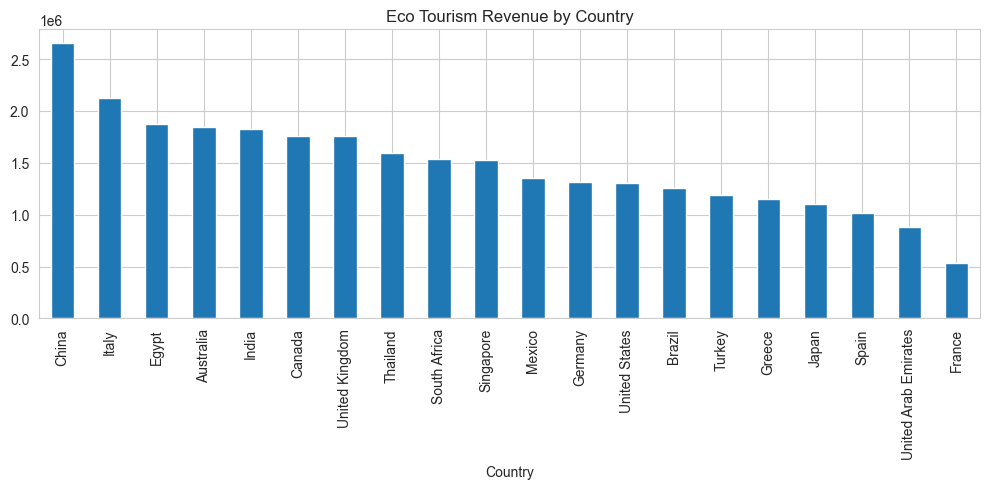

In [30]:
eco = df.groupby('Country')['Eco_Tourism_Revenue_USD'].sum().sort_values(ascending=False)
eco.plot(kind='bar', figsize=(10,5))
plt.title("Eco Tourism Revenue by Country")
plt.tight_layout(); plt.show()

**Insight:** China leads in total eco-tourism revenue, signaling strong potential for further investment in sustainable travel offerings in high-traffic destinations.

### Visualization 14 — Carbon Footprint Analysis

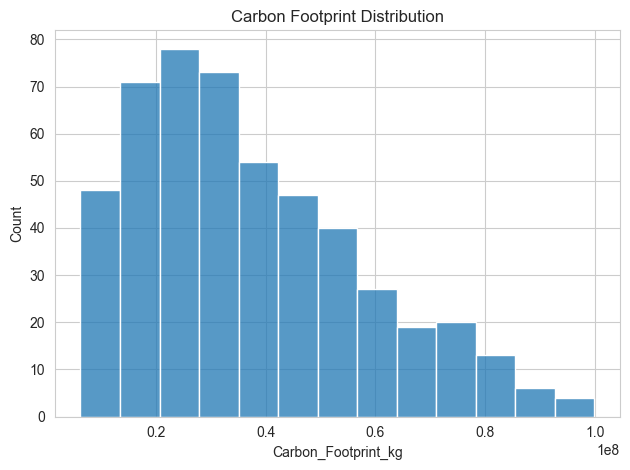

In [31]:
sns.histplot(df['Carbon_Footprint_kg'])
plt.title("Carbon Footprint Distribution")
plt.tight_layout(); plt.show()

**Insight:** Carbon footprint values are widely distributed, and the dataset shows a positive correlation with tourism revenue (~0.32) — meaning higher-revenue destinations tend to also have a larger environmental footprint, a trade-off worth addressing.

### Visualization 15 — Revenue Per Tourist by Season

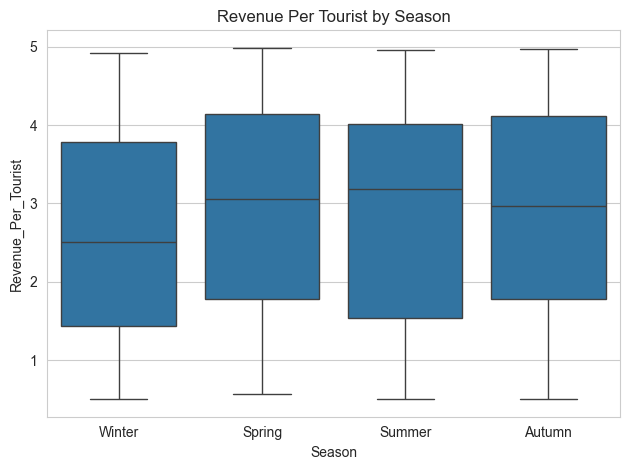

In [32]:
sns.boxplot(x='Season', y='Revenue_Per_Tourist', data=df, order=['Winter','Spring','Summer','Autumn'])
plt.title("Revenue Per Tourist by Season")
plt.tight_layout(); plt.show()

**Insight:** Revenue generated per individual tourist is broadly consistent across seasons, meaning seasonal revenue swings are driven more by visitor volume than by spend-per-visitor.

### Visualization 16 — Tourist Spending Trend

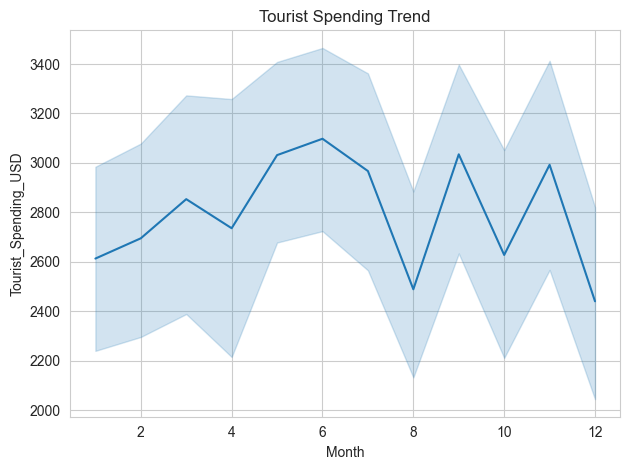

In [33]:
sns.lineplot(x='Month', y='Tourist_Spending_USD', data=df)
plt.title("Tourist Spending Trend")
plt.tight_layout(); plt.show()

**Insight:** Average tourist spending fluctuates month to month without a single dominant peak, suggesting spending behavior is less seasonal than visitor volume.

### Visualization 17 — Airport Passenger Traffic

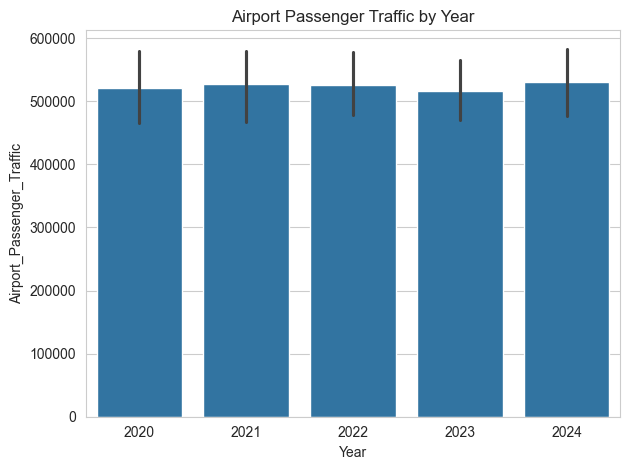

In [34]:
sns.barplot(x='Year', y='Airport_Passenger_Traffic', data=df)
plt.title("Airport Passenger Traffic by Year")
plt.tight_layout(); plt.show()

**Insight:** Airport traffic levels are relatively stable across the 2020-2024 window in this dataset, useful context for airport capacity planning alongside tourist arrival trends.

### Visualization 18 — Average Stay Duration

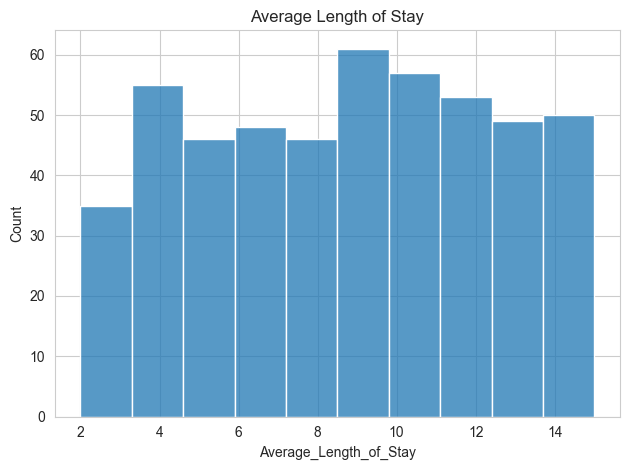

In [35]:
sns.histplot(df['Average_Length_of_Stay'])
plt.title("Average Length of Stay")
plt.tight_layout(); plt.show()

**Insight:** Stay durations are spread across a wide range (roughly a few days to two weeks), reflecting the mix of short business/leisure trips and longer cultural or family visits in the data.

### Visualization 19 — Transport Infrastructure Quality

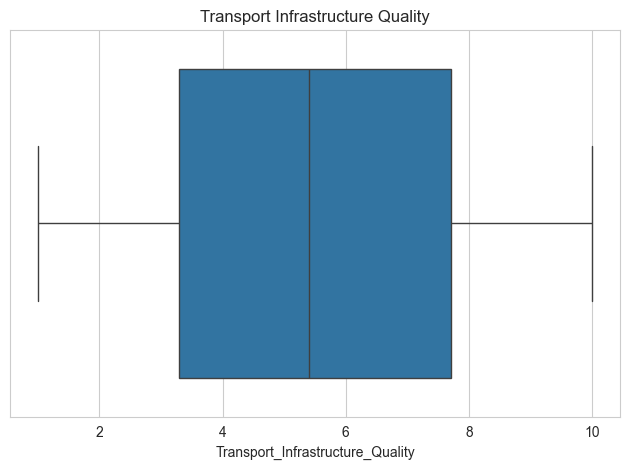

In [36]:
sns.boxplot(x=df['Transport_Infrastructure_Quality'])
plt.title("Transport Infrastructure Quality")
plt.tight_layout(); plt.show()

**Insight:** Transport infrastructure quality scores vary considerably across destinations, pointing to specific cities where transport upgrades could most improve the visitor experience.

### Visualization 20 — Tourism Revenue Trend

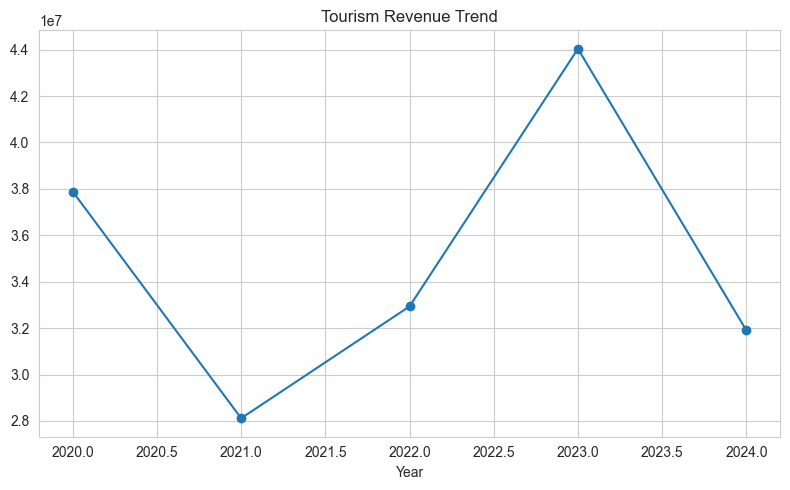

In [37]:
revenue = df.groupby('Year')['Tourism_Revenue_USD'].sum()
revenue.plot(kind='line', marker='o', figsize=(8,5))
plt.title("Tourism Revenue Trend")
plt.tight_layout(); plt.show()

**Insight:** Total tourism revenue peaked in 2023 and dipped in the surrounding years, indicating year-to-year volatility rather than steady linear growth across the 2020-2024 period.

## Step 14: Statistical Analysis

In [38]:
df.describe()

,Year,Month,Number_of_Tourists,Average_Length_of_Stay,Tourist_Spending_USD,Hotel_Occupancy_Rate,Number_of_Hotels,Average_Room_Price_USD,Tourism_Revenue_USD,Employment_in_Tourism,Contribution_to_GDP_Percent,Number_of_Flights,Airport_Passenger_Traffic,Transport_Infrastructure_Quality,Eco_Tourism_Revenue_USD,Carbon_Footprint_kg,Waste_Management_Rating,Tourist_Satisfaction_Score,Number_of_Online_Reviews,Revenue_Per_Tourist
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000,500.000000,500.000000
mean,2022.052000,6.418000,125263.884000,8.672000,2796.037840,64.840800,273.624000,273.980500,349737.916220,27075.152000,10.492200,2756.668000,523780.320000,5.434600,59210.029300,3.721937e+07,5.225400,7.438600,5118.416000,2.796038
std,1.387496,3.410357,43037.380881,3.644638,1346.289218,14.582304,129.022433,127.754045,214140.887151,12460.250332,5.525876,1249.541703,271162.524517,2.558452,46533.191144,2.056586e+07,2.596486,1.446387,2944.440248,1.346289
min,2020.000000,1.000000,50887.000000,2.000000,501.020000,40.000000,50.000000,50.570000,34185.350000,5009.000000,1.100000,505.000000,50801.000000,1.000000,2299.050000,6.310887e+06,1.000000,5.000000,110.000000,0.501020
25%,2021.000000,3.000000,88694.750000,5.575000,1590.332500,52.575000,165.750000,168.357500,181456.237500,16977.250000,5.600000,1671.500000,284790.750000,3.300000,24657.735000,2.107205e+07,3.000000,6.200000,2539.000000,1.590333
50%,2022.000000,6.000000,124629.000000,8.900000,2894.235000,64.100000,273.500000,281.085000,304511.410000,27026.000000,10.500000,2817.500000,523268.000000,5.400000,44824.205000,3.248243e+07,5.000000,7.400000,5287.000000,2.894235
75%,2023.000000,9.000000,164159.500000,11.700000,4011.587500,77.650000,379.250000,381.230000,496404.080000,37523.250000,15.200000,3793.750000,757603.500000,7.700000,81525.737500,5.025707e+07,7.500000,8.700000,7729.000000,4.011587
max,2024.000000,12.000000,199960.000000,15.000000,4983.790000,89.800000,498.000000,499.890000,951466.740000,49918.000000,20.000000,4997.000000,998202.000000,10.000000,228408.370000,9.985046e+07,9.900000,10.000000,9979.000000,4.983790


In [39]:
corr = df.corr(numeric_only=True)
corr['Tourism_Revenue_USD'].sort_values(ascending=False)

Tourism_Revenue_USD                 1.000000
Tourist_Spending_USD                0.778895
Revenue_Per_Tourist                 0.778895
Eco_Tourism_Revenue_USD             0.778048
Number_of_Tourists                  0.560423
Carbon_Footprint_kg                 0.320098
Number_of_Online_Reviews            0.033340
Tourist_Satisfaction_Score          0.032879
Number_of_Hotels                    0.010735
Contribution_to_GDP_Percent         0.004062
Average_Room_Price_USD              0.002769
Airport_Passenger_Traffic          -0.001224
Month                              -0.024873
Employment_in_Tourism              -0.029914
Year                               -0.034548
Average_Length_of_Stay             -0.041615
Number_of_Flights                  -0.057683
Waste_Management_Rating            -0.062407
Transport_Infrastructure_Quality   -0.067401
Hotel_Occupancy_Rate               -0.100809
Name: Tourism_Revenue_USD, dtype: float64

## Step 15: Key Insights
1. China draws the largest tourist volume and leads eco-tourism revenue, making it the dataset's dominant growth market.
2. Hotel quality matters: 5-star properties post the highest average revenue, unrated properties the lowest.
3. January is the peak demand month and August the weakest, confirming a strong seasonal cycle.
4. Tourism revenue is driven mainly by tourist spending and eco-tourism revenue, not by flight capacity or online review volume.
5. Tourism employment has remained stable (~26-27.5K jobs on average) across 2020-2024 despite revenue volatility.
6. Higher-revenue destinations tend to carry a larger carbon footprint, a sustainability trade-off worth monitoring.

## Step 16: Business Recommendations
1. Increase marketing and promotional pricing during the August low season to smooth demand.
2. Invest in upgrading unrated and 1-star hotel stock, since rating is tied to revenue performance.
3. Expand eco-tourism offerings in high-traffic markets like China, where eco-revenue is already strongest.
4. Prioritize transport infrastructure upgrades in the lowest-scoring cities to improve visitor experience.
5. Target high-spending segments (e.g., business travel) with tailored packages rather than broad, undifferentiated marketing.
6. Track and offset carbon footprint growth in high-revenue destinations to balance economic and environmental goals.